# California Campsite - Recommendation System

This notebook implements a **collaborative filtering recommendation system** and **natural language query interface** for California campsite reservations.

## Prerequisites
Run the main analysis notebook (`index.ipynb`) first to generate the cleaned data (`df_clean`), or load it from a saved file.

In [22]:
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries for recommendations
from sklearn.metrics.pairwise import cosine_similarity

# For natural language queries
import re
from datetime import datetime, timedelta


In [23]:
# Retrieve cleaned data from index.ipynb
%store -r df_clean

try:
    print(f"✓ Data loaded successfully: {len(df_clean)} rows")
    
    # Month names for display
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    df_clean.head()
except NameError:
    print("Please run index.ipynb first, then run this notebook.")
    raise

✓ Data loaded successfully: 216894 rows


In [24]:
# Step 1: Prepare Data for Collaborative Filtering

# Create user profiles based on booking patterns
df_recommendations = df_clean.copy()

# Create a user identifier based on booking characteristics
df_recommendations['user_profile'] = (
    df_recommendations['arrival_month'].astype(str) + '_' +
    df_recommendations['booking_month'].astype(str) + '_' +
    pd.cut(df_recommendations['lead_time_days'],
           bins=[0, 30, 90, 180, 365], labels=['immediate', 'short', 'medium', 'long']).astype(str) + '_' +
    pd.cut(df_recommendations['nights'], bins=[0, 2, 4, 7, 100], labels=['brief', 'weekend', 'week', 'extended']).astype(str)
)

# Create park/user interaction matrix (count of bookings)
park_user_matrix = df_recommendations.groupby(['user_profile', 'park']).size().reset_index(name='booking_count')

# Create a pivot table: rows = users, columns = parks, values = booking counts
interaction_matrix = park_user_matrix.pivot_table(
    index='user_profile',
    columns='park',
    values='booking_count',
    fill_value=0
)

print("="*70)
print("RECOMMENDATION SYSTEM - Data Preparation")
print("="*70)
print(f"Number of user profiles: {len(interaction_matrix)}")
print(f"Number of parks: {len(interaction_matrix.columns)}")
print(f"Matrix shape: {interaction_matrix.shape}")
print(f"\nTop 10 Parks by Total Bookings:")
print(interaction_matrix.sum(axis=0).sort_values(ascending=False).head(10))

RECOMMENDATION SYSTEM - Data Preparation
Number of user profiles: 897
Number of parks: 508
Matrix shape: (897, 508)

Top 10 Parks by Total Bookings:
park
Upper Pines Campground                                         11235.0
Inyo National Forest - Wilderness Permits                      10940.0
Yosemite National Park Wilderness Permits                       7849.0
JUMBO ROCKS CAMPGROUND                                          6352.0
PINNACLES CAMPGROUND                                            5298.0
Lodgepole Campground-Sequoia and Kings Canyon National Park     4870.0
Hodgdon Meadow Campground                                       4240.0
INDIAN COVE CAMPGROUND                                          4210.0
Wawona Campground                                               3832.0
FALLEN LEAF CAMPGROUND                                          3778.0
dtype: float64


In [25]:
# Step 2: Item-Based Collaborative Filtering (Parks Similar to Each Other)

# Calculate park similarity using cosine similarity
# Transpose so parks are rows and user profiles are columns
park_similarity = cosine_similarity(interaction_matrix.T)
park_similarity_df = pd.DataFrame(
    park_similarity,
    index=interaction_matrix.columns,
    columns=interaction_matrix.columns
)

def get_similar_parks(park_name, n=5):
    """Get n most similar parks to the given park"""
    if park_name not in park_similarity_df.index:
        return f"Park '{park_name}' not found in dataset"
    
    # Get similarity scores for the park, sort descending, exclude the park itself
    similar_parks = park_similarity_df[park_name].sort_values(ascending=False)[1:n+1]
    return similar_parks

# Test with a popular park
test_park = interaction_matrix.sum(axis=0).sort_values(ascending=False).index[0]

print("="*70)
print("ITEM-BASED COLLABORATIVE FILTERING")
print("="*70)
print(f"\nTesting with: {test_park}")
print(f"\nTop 5 Similar Parks:")

similar_parks = get_similar_parks(test_park, n=5)
for i, (park, similarity) in enumerate(similar_parks.items(), 1):
    print(f"{i}. {park}")
    print(f"   Similarity Score: {similarity:.4f}")

ITEM-BASED COLLABORATIVE FILTERING

Testing with: Upper Pines Campground

Top 5 Similar Parks:
1. Lower Pines Campground
   Similarity Score: 0.8696
2. Wawona Campground
   Similarity Score: 0.8686
3. Hodgdon Meadow Campground
   Similarity Score: 0.7981
4. POTWISHA CAMPGROUND
   Similarity Score: 0.7648
5. PINNACLES CAMPGROUND
   Similarity Score: 0.7371


# Park Recommendation System

Build a collaborative filtering recommendation system to suggest parks based on similar booking patterns.

In [26]:
# Step 3: User Based Recommendations

# Recommend parks for similar users
def recommend_parks_for_user_profile(user_profile, n=5, exclude_visited=True):
    if user_profile not in interaction_matrix.index:
        return f"User profile '{user_profile}' not found"
    
    # Calculate user similarity
    user_similarity = cosine_similarity(interaction_matrix)
    user_similarity_df = pd.DataFrame(
        user_similarity,
        index=interaction_matrix.index,
        columns=interaction_matrix.index
    )
    
    # Get top 10 similar users
    similar_users = user_similarity_df[user_profile].sort_values(ascending=False)[1:11]
    
    # Get parks those similar users visited
    user_parks = interaction_matrix.loc[user_profile]
    
    # Score parks based on similar users' preferences
    recommendations = {}
    for similar_user, similarity_score in similar_users.items():
        similar_user_parks = interaction_matrix.loc[similar_user]
        
        for park, count in similar_user_parks.items():
            if count > 0:  # They visited this park
                if exclude_visited and user_parks[park] > 0:
                    continue  # Skip parks already visited
                
                if park not in recommendations:
                    recommendations[park] = 0
                recommendations[park] += similarity_score * count
    
    # Sort by score
    recommendations = pd.Series(recommendations).sort_values(ascending=False).head(n)
    return recommendations

# Test with a user profile
test_user = interaction_matrix.index[0]

print("="*70)
print(f"User-Based Collaborative Filtering")
print("="*70)
print(f"\nTest User Profile: {test_user}")

# Parks visited by this user
user_visited = interaction_matrix.loc[test_user]
visited_parks = user_visited[user_visited > 0].sort_values(ascending=False)

print(f"\nParks visited by this user profile:")
for park, count in visited_parks.head(5).items():
    print(f"  • {park} ({int(count)} bookings)")

# Get park recommendations
recommendations = recommend_parks_for_user_profile(test_user, n=5)

print(f"\n\nRecommended Parks (based on similar campers):")
for i, (park, score) in enumerate(recommendations.items(), 1):
    print(f"{i}. {park}")
    print(f"   Recommendation Score: {score:.4f}")

User-Based Collaborative Filtering

Test User Profile: 1.0_10_medium_brief

Parks visited by this user profile:
  • JUMBO ROCKS CAMPGROUND (22 bookings)
  • INDIAN COVE CAMPGROUND (15 bookings)
  • Point Reyes National Seashore Campground (9 bookings)
  • Upper Pines Campground (7 bookings)
  • BLACK ROCK CAMPGROUND (5 bookings)


Recommended Parks (based on similar campers):
1. SANTA CRUZ SCORPION
   Recommendation Score: 46.3833
2. Indian Cove Group
   Recommendation Score: 27.4842
3. PLASKETT CREEK CAMPGROUND
   Recommendation Score: 26.7266
4. Joshua Tree National Park Wilderness Backpacking Permits
   Recommendation Score: 18.5632
5. POTWISHA CAMPGROUND
   Recommendation Score: 17.5864


VISUALIZATIONS


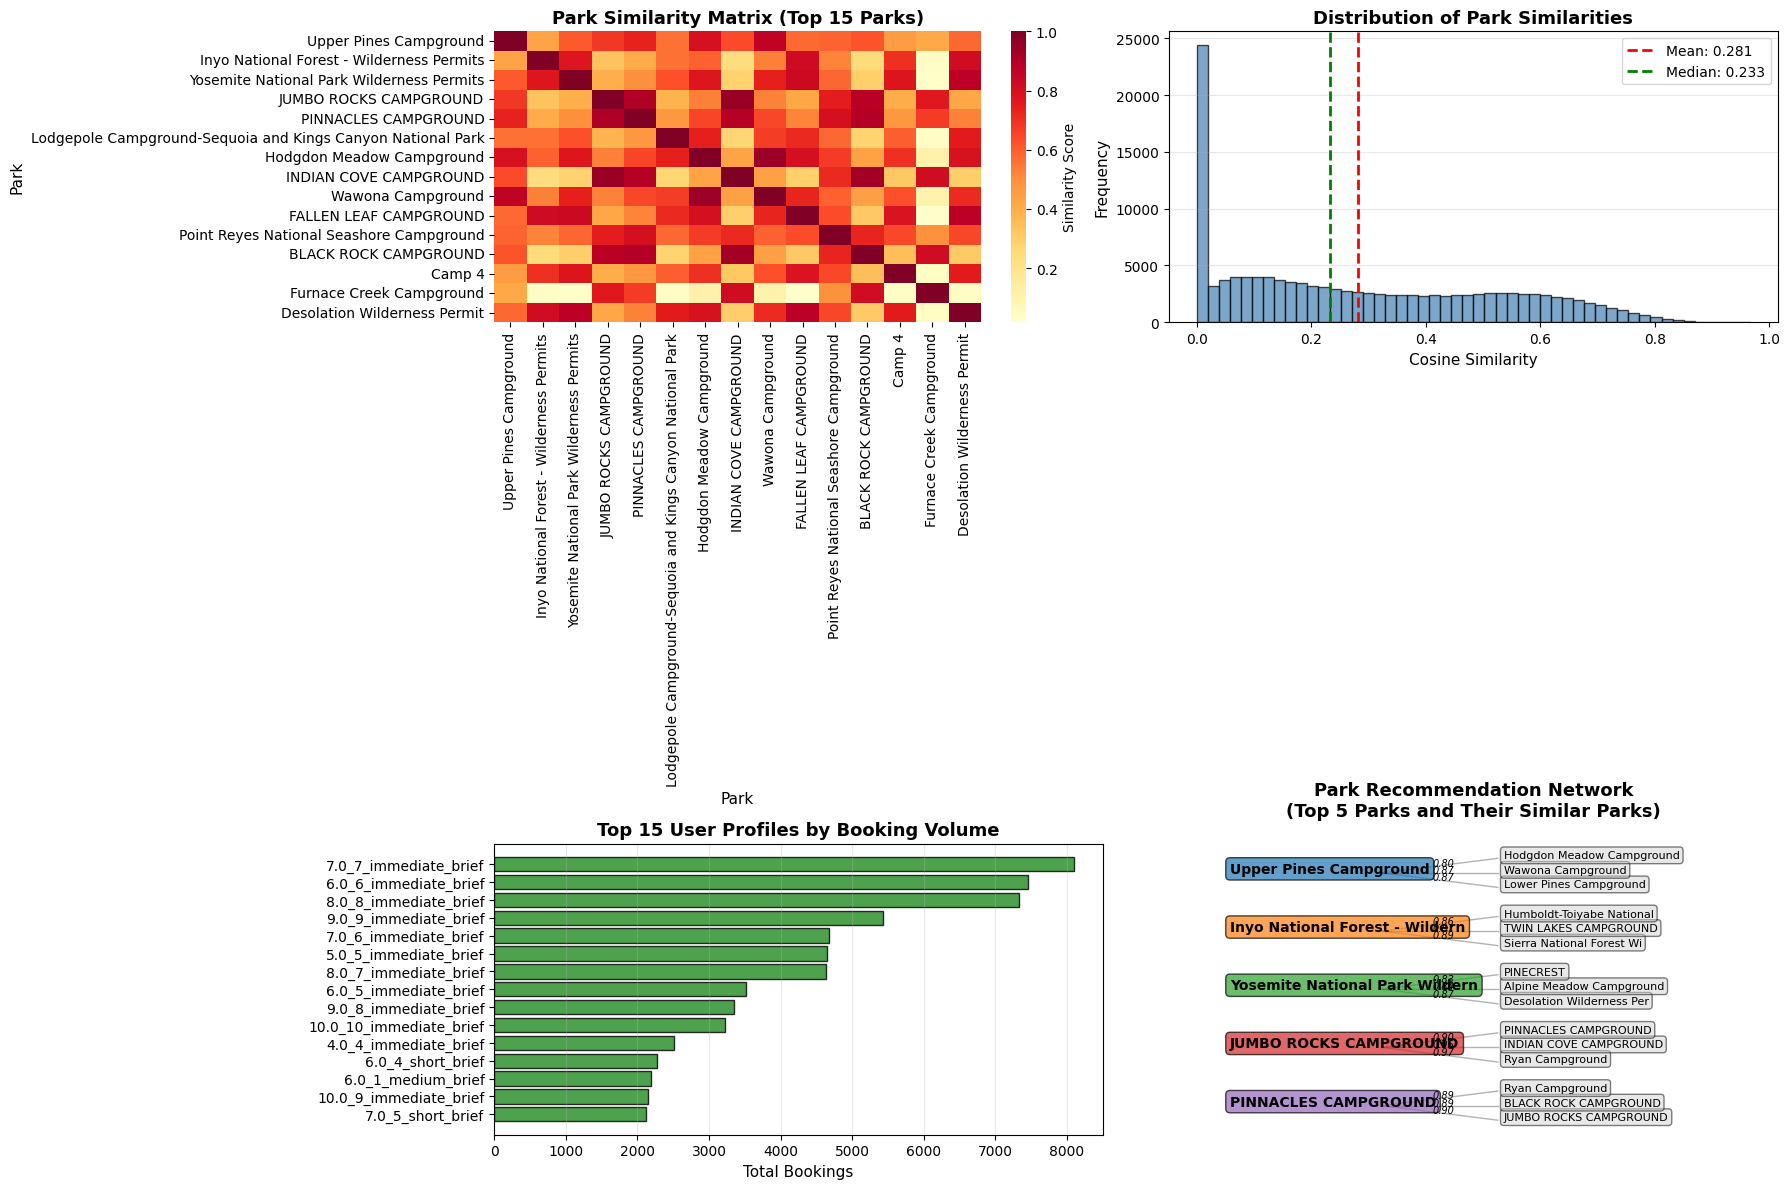

In [27]:
# Step 4: Visualizations

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Top 15 Similar Parks
top_15_parks = interaction_matrix.sum(axis=0).sort_values(ascending=False).head(15).index
similarity_subset = park_similarity_df.loc[top_15_parks, top_15_parks]

sns.heatmap(similarity_subset, annot=False, cmap='YlOrRd', cbar_kws={'label': 'Similarity Score'}, ax=axes[0, 0])
axes[0, 0].set_title('Park Similarity Matrix (Top 15 Parks)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Park', fontsize=11)
axes[0, 0].set_ylabel('Park', fontsize=11)

# 2. Distribution of Similarity Scores
similarity_values = park_similarity_df.values[np.triu_indices_from(park_similarity_df.values, k=1)]
axes[0, 1].hist(similarity_values, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].axvline(similarity_values.mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {similarity_values.mean():.3f}')
axes[0, 1].axvline(np.median(similarity_values), color='green', linestyle='--', linewidth=2,
                   label=f'Median: {np.median(similarity_values):.3f}')
axes[0, 1].set_xlabel('Cosine Similarity', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Distribution of Park Similarities', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. User Profile Distribution
profile_counts = park_user_matrix.groupby('user_profile')['booking_count'].sum().sort_values(ascending=False).head(15)
axes[1, 0].barh(range(len(profile_counts)), profile_counts.values, color='forestgreen', edgecolor='black', alpha=0.8)
axes[1, 0].set_yticks(range(len(profile_counts)))
axes[1, 0].set_yticklabels([label[:40] + '...' if len(label) > 40 else label for label in profile_counts.index])
axes[1, 0].set_xlabel('Total Bookings', fontsize=11)
axes[1, 0].set_title('Top 15 User Profiles by Booking Volume', fontsize=13, fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Example Recommendations Network (Top 5 parks and their top 3 similar parks)
top_5_parks = interaction_matrix.sum(axis=0).sort_values(ascending=False).head(5).index

# Create a simple network visualization
ax = axes[1, 1]
ax.axis('off')
ax.set_title('Park Recommendation Network\n(Top 5 Parks and Their Similar Parks)', 
             fontsize=13, fontweight='bold', pad=20)

y_positions = np.linspace(0.9, 0.1, len(top_5_parks))
colors_network = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, park in enumerate(top_5_parks):
    # Main park
    ax.text(0.1, y_positions[i], park[:30], fontsize=10, fontweight='bold', 
            bbox=dict(boxstyle='round', facecolor=colors_network[i], alpha=0.7))
    
    # Similar parks
    similar = get_similar_parks(park, n=3)
    for j, (similar_park, score) in enumerate(similar.items()):
        y_offset = y_positions[i] + (j - 1) * 0.05
        ax.text(0.55, y_offset, f"{similar_park[:25]}", fontsize=8,
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
        ax.plot([0.35, 0.54], [y_positions[i], y_offset], 'k-', alpha=0.3, linewidth=1)
        ax.text(0.45, (y_positions[i] + y_offset) / 2, f'{score:.2f}', 
                fontsize=7, ha='center', style='italic')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()

print("="*70)
print(f"VISUALIZATIONS")
print("="*70)

plt.show()


# Natural Language Query System

In [28]:
# Step 6: Natural Language Query Parser

def parse_query(query):
    """Parse natural language query to extract intent and parameters"""
    query_lower = query.lower()
    
    # Initialize parameters
    intent = None
    park_name = None
    month = None
    timeframe = None
    
    # Detect intent
    if any(word in query_lower for word in ['available', 'availability', 'book now', 'last minute', 'last-minute']):
        intent = 'availability'
    elif any(word in query_lower for word in ['lead time', 'how far', 'advance', 'how early', 'how soon']):
        intent = 'lead_time'
    elif any(word in query_lower for word in ['recommend', 'suggest', 'similar', 'like']):
        intent = 'recommend'
    elif any(word in query_lower for word in ['popular', 'best', 'top']):
        intent = 'popular'
    elif any(word in query_lower for word in ['when', 'what time', 'what month']):
        intent = 'timing'
    
    # Extract park name (look for capitalized words or known parks)
    park_names = df_clean['park'].unique()
    for park in park_names:
        if park.lower() in query_lower:
            park_name = park
            break
    
    # Month and season mapping
    month_names = {
        'january': 1, 'jan': 1, 'february': 2, 'feb': 2, 'march': 3, 'mar': 3,
        'april': 4, 'apr': 4, 'may': 5, 'june': 6, 'jun': 6,
        'july': 7, 'jul': 7, 'august': 8, 'aug': 8, 'september': 9, 'sep': 9,
        'october': 10, 'oct': 10, 'november': 11, 'nov': 11, 'december': 12, 'dec': 12,
        'summer': [6, 7, 8], 'winter': [12, 1, 2], 'spring': [3, 4, 5], 'fall': [9, 10, 11]
    }
    
    for month_str, month_num in month_names.items():
        if month_str in query_lower:
            month = month_num
            break
    
    # Detect timeframe
    if any(word in query_lower for word in ['last minute', 'last-minute', 'now', 'today', 'this week']):
        timeframe = 'immediate'
    elif any(word in query_lower for word in ['next week', 'soon']):
        timeframe = 'short'
    elif any(word in query_lower for word in ['next month', 'few weeks']):
        timeframe = 'medium'
    elif any(word in query_lower for word in ['months ahead', 'far ahead', 'advance']):
        timeframe = 'long'
    
    return {
        'intent': intent,
        'park_name': park_name,
        'month': month,
        'timeframe': timeframe,
        'original_query': query
    }

print("✓ Query parser initialized")
print("\nSupported query types:")
print("  1. Availability queries (e.g., 'What's available last minute?')")
print("  2. Lead time queries (e.g., 'How far ahead to book Yosemite?')")
print("  3. Recommendations (e.g., 'Suggest parks similar to Big Sur')")
print("  4. Popular parks (e.g., 'What are the most popular parks in summer?')")
print("  5. Timing queries (e.g., 'When is the best time to visit?')")

✓ Query parser initialized

Supported query types:
  1. Availability queries (e.g., 'What's available last minute?')
  2. Lead time queries (e.g., 'How far ahead to book Yosemite?')
  3. Recommendations (e.g., 'Suggest parks similar to Big Sur')
  4. Popular parks (e.g., 'What are the most popular parks in summer?')
  5. Timing queries (e.g., 'When is the best time to visit?')


In [29]:
# Step 7: Query Response Generator

def answer_query(query):
    """Generate intelligent responses to natural language queries"""
    parsed = parse_query(query)
    
    print("="*70)
    print(f"QUERY: {parsed['original_query']}")
    print("="*70)
    
    intent = parsed['intent']
    park_name = parsed['park_name']
    month = parsed['month']
    timeframe = parsed['timeframe']
    
    # AVAILABILITY QUERIES
    if intent == 'availability':
        print("\nAVAILABILITY ANALYSIS\n")
        
        if timeframe == 'immediate':
            # Parks with shortest lead times - most likely less popular with availability
            avg_lead_by_park = df_clean.groupby('park')['lead_time_days'].agg(['mean', 'median', 'count']).reset_index()
            avg_lead_by_park = avg_lead_by_park[avg_lead_by_park['count'] >= 10]  # Filter parks with enough data
            avg_lead_by_park = avg_lead_by_park.sort_values('median')
            
            print("Parks Most Likely Available for Last-Minute Bookings:")
            print("*Based on historically short lead times\n")
            
            for i, row in avg_lead_by_park.head(10).iterrows():
                print(f"   {i+1}. {row['park']}")
                print(f"      • Median Lead Time: {row['median']:.0f} days")
                print(f"      • Average Lead Time: {row['mean']:.0f} days")
                print(f"      • Bookings Analyzed: {int(row['count'])}\n")
            
            print(f"\nTIP: Parks with shorter lead times typically have more flexible availability.")
            print(f"Consider booking within the next {avg_lead_by_park.head(1)['median'].values[0]:.0f} days for best results.")
        
        elif month:
            if isinstance(month, list):  # Season
                season_name = [k for k, v in {'summer': [6,7,8], 'winter': [12,1,2], 'spring': [3,4,5], 'fall': [9,10,11]}.items() if v == month][0]
                month_filter = df_clean['arrival_month'].isin(month)
                print(f"Analyzing {season_name.title()} availability...\n")
            else:
                month_filter = df_clean['arrival_month'] == month
                print(f"Analyzing {months[month-1]} availability...\n")
            
            month_data = df_clean[month_filter]
            park_popularity = month_data.groupby('park').size().sort_values(ascending=True)
            
            print(f"Parks with lowest booking volume:\n")
            for i, (park, count) in enumerate(park_popularity.head(10).items(), 1):
                avg_lead = month_data[month_data['park'] == park]['lead_time_days'].median()
                print(f"   {i}. {park}")
                print(f"Booking Volume: {int(count)} reservations")
                print(f"Median Lead Time: {avg_lead:.0f} days\n")
    
    # LEAD TIME QUERIES
    elif intent == 'lead_time':
        print("\nLEAD TIME ANALYSIS\n")
        
        if park_name:
            park_data = df_clean[df_clean['park'] == park_name]
            
            if len(park_data) > 0:
                print(f"Park: {park_name}\n")
                
                lead_stats = park_data['lead_time_days'].describe()
                print(f"Lead Time Statistics:")
                print(f"Mean: {lead_stats['mean']:.0f} days")
                print(f"Median: {lead_stats['50%']:.0f} days")
                print(f"75th Percentile: {lead_stats['75%']:.0f} days")
                print(f"90th Percentile: {park_data['lead_time_days'].quantile(0.9):.0f} days")
                
                # By month if available
                if month:
                    if isinstance(month, list):
                        month_filter = park_data['arrival_month'].isin(month)
                    else:
                        month_filter = park_data['arrival_month'] == month
                    
                    month_park_data = park_data[month_filter]
                    if len(month_park_data) > 0:
                        month_median = month_park_data['lead_time_days'].median()
                        print(f"\nFor {months[month-1] if isinstance(month, int) else 'selected season'}:")
                        print(f"Recommended Lead Time: {month_median:.0f} days")
                
                print(f"\nRECOMMENDATION:")
                percentile_90 = park_data['lead_time_days'].quantile(0.9)
                print(f"Book at least {percentile_90:.0f} days in advance to secure a spot")
                print(f"*This covers 90% of historical bookings")
            else:
                print(f"No data found for '{park_name}'")
        else:
            # General lead time by month
            if month:
                if isinstance(month, list):
                    month_filter = df_clean['arrival_month'].isin(month)
                    month_name = "selected season"
                else:
                    month_filter = df_clean['arrival_month'] == month
                    month_name = months[month-1]
                
                month_data = df_clean[month_filter]
                median_lead = month_data['lead_time_days'].median()
                percentile_90 = month_data['lead_time_days'].quantile(0.9)
                
                print(f"For {month_name}:")
                print(f"Median Lead Time: {median_lead:.0f} days")
                print(f"90th Percentile: {percentile_90:.0f} days")
                print(f"\nECOMMENDATION: Book {percentile_90:.0f}+ days ahead for {month_name}")
            else:
                # Overall statistics
                overall_median = df_clean['lead_time_days'].median()
                overall_90 = df_clean['lead_time_days'].quantile(0.9)
                print(f"Overall Lead Time Statistics:")
                print(f"Median: {overall_median:.0f} days")
                print(f"90th Percentile: {overall_90:.0f} days")
                print(f"\nGENERAL RULE: Book {overall_90:.0f}+ days in advance")
    
    # RECOMMENDATION QUERIES
    elif intent == 'recommend':
        print("\nPARK RECOMMENDATIONS\n")
        
        if park_name and park_name in park_similarity_df.index:
            similar_parks = get_similar_parks(park_name, n=5)
            print(f"Because you like {park_name}, try these similar parks:\n")
            
            for i, (park, similarity) in enumerate(similar_parks.items(), 1):
                park_bookings = interaction_matrix[park].sum()
                park_lead = df_clean[df_clean['park'] == park]['lead_time_days'].median()
                print(f"{i}. {park}")
                print(f"Similarity Score: {similarity:.3f}")
                print(f"Popularity: {int(park_bookings)} bookings")
                print(f"Typical Lead Time: {park_lead:.0f} days\n")
        else:
            # Show top parks by season if month specified
            if month:
                if isinstance(month, list):
                    month_filter = df_clean['arrival_month'].isin(month)
                    season_name = [k for k, v in {'summer': [6,7,8], 'winter': [12,1,2], 'spring': [3,4,5], 'fall': [9,10,11]}.items() if v == month][0]
                    print(f"Top Parks for {season_name.title()}:\n")
                else:
                    month_filter = df_clean['arrival_month'] == month
                    print(f"Top Parks for {months[month-1]}:\n")
                
                month_parks = df_clean[month_filter].groupby('park').size().sort_values(ascending=False).head(10)
                for i, (park, count) in enumerate(month_parks.items(), 1):
                    print(f"{i}. {park} - {int(count)} bookings")
    
    # POPULAR PARKS QUERIES
    elif intent == 'popular':
        print("\nMOST POPULAR PARKS\n")
        
        if month:
            if isinstance(month, list):
                month_filter = df_clean['arrival_month'].isin(month)
                season_name = [k for k, v in {'summer': [6,7,8], 'winter': [12,1,2], 'spring': [3,4,5], 'fall': [9,10,11]}.items() if v == month][0]
                print(f"Top Parks in {season_name.title()}:\n")
            else:
                month_filter = df_clean['arrival_month'] == month
                print(f"Top Parks in {months[month-1]}:\n")
            
            month_parks = df_clean[month_filter].groupby('park').agg({
                'park': 'size',
                'lead_time_days': 'median'
            }).rename(columns={'park': 'bookings'}).sort_values('bookings', ascending=False).head(10)
            
            for i, (park, row) in enumerate(month_parks.iterrows(), 1):
                print(f"{i}. {park}")
                print(f"Bookings: {int(row['bookings'])}")
                print(f"Median Lead Time: {row['lead_time_days']:.0f} days\n")
        else:
            top_parks = df_clean.groupby('park').agg({
                'park': 'size',
                'lead_time_days': 'median'
            }).rename(columns={'park': 'bookings'}).sort_values('bookings', ascending=False).head(10)
            
            print("Overall Most Popular Parks:\n")
            for i, (park, row) in enumerate(top_parks.iterrows(), 1):
                print(f"{i}. {park}")
                print(f"Bookings: {int(row['bookings'])}")
                print(f"Median Lead Time: {row['lead_time_days']:.0f} days\n")
    
    # TIMING QUERIES
    elif intent == 'timing':
        print("\nBEST TIMING ANALYSIS\n")
        
        if park_name:
            park_data = df_clean[df_clean['park'] == park_name]
            if len(park_data) > 0:
                monthly_bookings = park_data.groupby('arrival_month').size().sort_values(ascending=False)
                
                print(f"Best months to visit {park_name}:\n")
                for i, (month_num, count) in enumerate(monthly_bookings.head(5).items(), 1):
                    month_lead = park_data[park_data['arrival_month'] == month_num]['lead_time_days'].median()
                    print(f"{i}. {months[month_num-1]}")
                    print(f"Bookings: {int(count)}")
                    print(f"Median Lead Time: {month_lead:.0f} days\n")
        else:
            monthly_bookings = df_clean.groupby('arrival_month').size().sort_values(ascending=False)
            print("Best months for camping overall:\n")
            for i, (month_num, count) in enumerate(monthly_bookings.head(5).items(), 1):
                print(f"{i}. {months[month_num-1]} - {int(count)} bookings")
    
    else:
        print("\nQuery not understood. Try asking another question")


In [30]:
# Step 8: Interactive Query Examples

print("="*70)
print("NATURAL LANGUAGE QUERY SYSTEM - DEMO")
print("="*70)

# Example 1: Last minute availability
answer_query("What campsites are likely available for a last minute trip next weekend?")

# Example 2: Specific park lead time
popular_park = df_clean['park'].value_counts().index[0] # Use a popular park for the example
answer_query(f"What is the average lead time to book a campsite in {popular_park}?")

# Example 3: Summer recommendations
answer_query("What are the most popular parks for summer camping?")

# Example 4: Similar park recommendations
if len(df_clean['park'].unique()) > 1:
    second_popular_park = df_clean['park'].value_counts().index[1]
    answer_query(f"Recommend parks similar to {second_popular_park}")

# Example 5: Timing query
answer_query("When is the best time to book for July?")

# Example 5: Lead time query
answer_query("What is the average lead time for all parks?")



NATURAL LANGUAGE QUERY SYSTEM - DEMO
QUERY: What campsites are likely available for a last minute trip next weekend?

AVAILABILITY ANALYSIS

Parks Most Likely Available for Last-Minute Bookings:
*Based on historically short lead times

   449. San Bernardino National Forest Day Use Pass
      • Median Lead Time: 0 days
      • Average Lead Time: 2 days
      • Bookings Analyzed: 41

   233. Half Dome Permits
      • Median Lead Time: 1 days
      • Average Lead Time: 51 days
      • Bookings Analyzed: 3219

   123. Crystal Springs Campground (CA)
      • Median Lead Time: 1 days
      • Average Lead Time: 1 days
      • Bookings Analyzed: 261

   117. Clear Creek Management Area
      • Median Lead Time: 1 days
      • Average Lead Time: 4 days
      • Bookings Analyzed: 386

   140. Death Valley Backcountry Roadside Camping
      • Median Lead Time: 2 days
      • Average Lead Time: 8 days
      • Bookings Analyzed: 14

   19. Aquatic Park Cove, Black Point Overnight Anchoring, Sailin